In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# --- 1. DATA COLLECTION: FETCHING CONSTITUENTS ---

def get_sp500_tickers():
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    table = pd.read_html(url)
    df = table[0]
    return df['Symbol'].tolist()

def get_csi300_tickers():
    # CSI 300 uses numeric codes. These are the top 10 liquid proxies.
    # In a full production environment, you would scrape the full 300 list.
    return ['600519.SS', '601318.SS', '300750.SZ', '600036.SS', '000333.SZ', 
            '000858.SZ', '600900.SS', '601166.SS', '601899.SS', '600030.SS']

# --- 2. CALCULATING EQUITY BREADTH (% ABOVE 200-DAY SMA) ---

def calculate_breadth(tickers, start_date="2023-01-01"):
    print(f"Downloading data for {len(tickers)} tickers...")
    data = yf.download(tickers, start=start_date)['Close']
    sma200 = data.rolling(window=200).mean()
    # Percent of stocks where Price > SMA200
    breadth = (data > sma200).mean(axis=1)
    return breadth.dropna()

# Fetch US and China Breadth
sp500_tickers = get_sp500_tickers()
csi300_tickers = get_csi300_tickers()

us_breadth = calculate_breadth(sp500_tickers)
cn_breadth = calculate_breadth(csi300_tickers)

# --- 3. FX PCA ANALYSIS ---

# Global FX Basket (vs USD)
fx_tickers = ['EURUSD=X', 'JPYUSD=X', 'GBPUSD=X', 'AUDUSD=X', 'NZDUSD=X', 
              'CADUSD=X', 'CHFUSD=X', 'NOKUSD=X', 'SEKUSD=X']

fx_prices = yf.download(fx_tickers, start="2023-01-01")['Close']
fx_returns = fx_prices.pct_change().dropna()

# Standardize and Run PCA
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(fx_returns)
pca = PCA(n_components=3)
pca.fit(scaled_returns)

# Factor Loadings Table
loadings = pd.DataFrame(pca.components_.T, index=fx_tickers, columns=['PC1_USD', 'PC2_CN', 'PC3'])
print("\n--- PCA Loadings (Identify US vs China Sensitivity) ---")
print(loadings)

# --- 4. PREDICTIVE INTERACTION TEST ---

# Align all data
master_df = pd.DataFrame({
    'US_Breadth': us_breadth,
    'CN_Breadth': cn_breadth
}).join(fx_returns).dropna()

results = []

for ticker in fx_tickers:
    # Dependent variable: T+1 Return
    y = master_df[ticker].shift(-1).dropna()
    
    # Independent variables: Interaction (Loading * Breadth)
    X = pd.DataFrame(index=y.index)
    X['US_Interaction'] = master_df.loc[y.index, 'US_Breadth'] * loadings.loc[ticker, 'PC1_USD']
    X['CN_Interaction'] = master_df.loc[y.index, 'CN_Breadth'] * loadings.loc[ticker, 'PC2_CN']
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    results.append({
        'Currency': ticker,
        'US_Beta': model.params['US_Interaction'],
        'US_Pval': model.pvalues['US_Interaction'],
        'CN_Beta': model.params['CN_Interaction'],
        'CN_Pval': model.pvalues['CN_Interaction']
    })

# Output Results
results_df = pd.DataFrame(results).set_index('Currency')
print("\n--- Predictive Power of Breadth-Weighted Factors ---")
print(results_df)

In [ ]:
# ============================================================
# PCA of Global FX Markets + US/China Breadth Predictive Study
# ============================================================
#
# What this does:
# 1. Downloads a panel of global FX proxies from Yahoo Finance
# 2. Builds daily log returns
# 3. Runs PCA on standardized FX returns
# 4. Computes rolling PCA factors
# 5. Merges in US and China breadth series
# 6. Tests predictive regressions for forward returns
# 7. Tests exposure-based panel regressions:
#       do currencies with larger China / US loadings respond
#       more strongly to China / US breadth?
# 8. Produces plots and summary outputs
#
# Notes:
# - Yahoo Finance is imperfect for FX coverage. This is a practical starting point.
# - For China breadth, this script expects a CSV you already have.
# - For US breadth, this script computes the breadth from a list of ETFs by default.
#   You can replace that with a true stock-universe breadth series if you have one.
#
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# =========================
# 0. USER SETTINGS
# =========================

START_DATE = "2012-01-01"
END_DATE = None

# Forward return horizon for prediction
HORIZON_DAYS = 20

# Rolling PCA window
ROLLING_PCA_WINDOW = 252

# Number of PCA components
N_COMPONENTS = 5

# Breadth windows
SMA_WINDOW = 200
BREADTH_Z_WINDOW = 252

# Minimum observations required in regressions
MIN_OBS = 150
MIN_PCA_OBS = 252

# -------------------------
# FX universe
# -------------------------
# Yahoo tickers here are mostly USD quoted against foreign currencies or vice versa.
# Sign direction matters for interpretation, so we standardize and later interpret PCs.
#
# If you want cleaner consistency, you can invert some pairs manually later.
FX_TICKERS = {
    "EURUSD": "EURUSD=X",
    "JPY": "JPY=X",          # USDJPY proxy on Yahoo style; sign direction may differ
    "GBPUSD": "GBPUSD=X",
    "AUDUSD": "AUDUSD=X",
    "NZDUSD": "NZDUSD=X",
    "CAD": "CAD=X",
    "CHF": "CHF=X",
    "SEK": "SEK=X",
    "NOK": "NOK=X",
    "MXN": "MXN=X",
    "BRL": "BRL=X",
    "ZAR": "ZAR=X",
    "INR": "INR=X",
    "KRW": "KRW=X",
    "SGD": "SGD=X",
    "TWD": "TWD=X",
    "CNH": "CNH=X",
    "HKD": "HKD=X",
}

# -------------------------
# Asset targets for prediction
# -------------------------
# You can predict FX series themselves or ETFs.
TARGET_TICKERS = {
    "FXI": "FXI",   # China large cap ETF
    "EWH": "EWH",   # Hong Kong
    "EWJ": "EWJ",   # Japan
    "EWY": "EWY",   # Korea
    "EWA": "EWA",   # Australia
    "UUP": "UUP",   # USD ETF proxy
    "EEM": "EEM",   # EM equities
}

# -------------------------
# US breadth universe
# -------------------------
# This is a practical ETF breadth proxy, not a true all-stock universe breadth.
# Replace with your real US breadth series if you have one.
US_BREADTH_UNIVERSE = [
    "SPY", "QQQ", "IWM", "XLF", "XLK", "XLI", "XLE", "XLY", "XLP", "XLV",
    "XLB", "XLU", "XLRE", "XLC", "SMH", "KRE", "ARKK", "IBB", "SOXX"
]

# -------------------------
# File paths
# -------------------------
# China breadth CSV should ideally have columns:
#   Date, Breadth
# where Breadth is % above 200-day SMA
CHINA_BREADTH_CSV = "china_breadth.csv"

# Optional: If you already have a real US breadth CSV, set this to a path
# with columns Date, Breadth. Otherwise the script builds an ETF-based proxy.
US_BREADTH_CSV = None

OUTPUT_DIR = Path("fx_pca_breadth_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# =========================
# 1. HELPERS
# =========================

def download_close(tickers, start=START_DATE, end=END_DATE):
    """
    Download adjusted close prices from Yahoo.
    Returns DataFrame indexed by date, columns = given keys if dict.
    """
    if isinstance(tickers, dict):
        raw = yf.download(
            list(tickers.values()),
            start=start,
            end=end,
            auto_adjust=True,
            progress=False,
            group_by="ticker"
        )

        out = pd.DataFrame(index=raw.index)
        for name, ticker in tickers.items():
            try:
                if ("Close" in raw[ticker].columns):
                    out[name] = raw[ticker]["Close"]
                else:
                    out[name] = raw[ticker]
            except Exception:
                out[name] = np.nan
        return out.sort_index()

    else:
        raw = yf.download(
            tickers,
            start=start,
            end=end,
            auto_adjust=True,
            progress=False
        )
        if isinstance(raw.columns, pd.MultiIndex):
            return raw["Close"].sort_index()
        return raw.rename("Close").to_frame().sort_index()


def compute_log_returns(prices):
    return np.log(prices / prices.shift(1)).dropna(how="all")


def compute_forward_log_returns(prices, horizon=20):
    return np.log(prices.shift(-horizon) / prices)


def safe_standardize(df):
    """
    Cross-column standardization using full-sample mean/std.
    """
    return (df - df.mean()) / df.std(ddof=0)


def prepare_pca_panel(df, min_obs=MIN_PCA_OBS):
    valid_counts = df.notna().sum()
    keep_cols = valid_counts[valid_counts >= min_obs].index.tolist()
    dropped_cols = [col for col in df.columns if col not in keep_cols]

    if dropped_cols:
        print(f"Dropping sparse FX series before PCA: {dropped_cols}")

    clean = df[keep_cols].dropna()

    if clean.empty:
        raise ValueError(
            "No overlapping FX return history remains after filtering sparse columns. "
            "Check Yahoo coverage or lower MIN_PCA_OBS."
        )

    return clean


def run_pca(df, n_components=5):
    """
    PCA on columns of df after dropping rows with missing data.
    Returns scores, loadings, explained variance ratio.
    """
    clean = prepare_pca_panel(df)
    n_components = min(n_components, clean.shape[0], clean.shape[1])
    scaler = StandardScaler()
    X = scaler.fit_transform(clean.values)

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X)

    score_df = pd.DataFrame(
        scores,
        index=clean.index,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    loading_df = pd.DataFrame(
        pca.components_.T,
        index=clean.columns,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    explained = pd.Series(
        pca.explained_variance_ratio_,
        index=[f"PC{i+1}" for i in range(n_components)],
        name="ExplainedVarianceRatio"
    )

    return score_df, loading_df, explained


def rolling_pca_scores(df, window=252, n_components=3):
    """
    Rolling PCA scores using only past data at each date.
    Returns time series of PC scores aligned to the end of each window,
    and average loadings over time.
    """
    cols = [f"PC{i+1}" for i in range(n_components)]
    score_rows = []
    loading_list = []

    clean = prepare_pca_panel(df)

    if len(clean) < window:
        raise ValueError(
            f"Not enough overlapping FX history for rolling PCA: {len(clean)} rows, window={window}."
        )

    n_components = min(n_components, clean.shape[0], clean.shape[1])

    for i in range(window, len(clean) + 1):
        sub = clean.iloc[i-window:i]
        scaler = StandardScaler()
        X = scaler.fit_transform(sub.values)

        pca = PCA(n_components=n_components)
        scores = pca.fit_transform(X)

        # Keep only the most recent score from the window
        score_rows.append(
            pd.Series(scores[-1], index=cols, name=sub.index[-1])
        )

        loading_df = pd.DataFrame(
            pca.components_.T,
            index=sub.columns,
            columns=cols
        )
        loading_df["date"] = sub.index[-1]
        loading_list.append(loading_df.reset_index().rename(columns={"index": "asset"}))

    score_df = pd.DataFrame(score_rows)
    loading_hist = pd.concat(loading_list, axis=0, ignore_index=True)

    return score_df, loading_hist


def compute_breadth_from_prices(prices, sma_window=200):
    """
    Breadth = % of columns above their SMA window.
    """
    sma = prices.rolling(sma_window).mean()
    above = (prices > sma).astype(float)
    breadth = 100 * above.mean(axis=1)
    return breadth.rename("Breadth")


def load_breadth_csv(path, value_col="Breadth"):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")
    return df[value_col].astype(float).rename("Breadth")


def build_us_breadth():
    """
    If no US breadth CSV is supplied, build ETF proxy breadth.
    """
    if US_BREADTH_CSV is not None and Path(US_BREADTH_CSV).exists():
        us_breadth = load_breadth_csv(US_BREADTH_CSV)
    else:
        us_prices = download_close(US_BREADTH_UNIVERSE)
        us_breadth = compute_breadth_from_prices(us_prices, sma_window=SMA_WINDOW)
    return us_breadth.rename("US_Breadth")


def build_china_breadth():
    china_path = Path(CHINA_BREADTH_CSV)
    if not china_path.exists():
        raise FileNotFoundError(
            f"China breadth CSV not found at: {china_path.resolve()}\n"
            "Create a CSV with columns Date,Breadth and point CHINA_BREADTH_CSV to it."
        )
    china_breadth = load_breadth_csv(china_path)
    return china_breadth.rename("China_Breadth")


def add_breadth_features(df, us_col="US_Breadth", china_col="China_Breadth"):
    out = df.copy()

    out["US_Breadth_5dChange"] = out[us_col].diff(5)
    out["China_Breadth_5dChange"] = out[china_col].diff(5)

    out["US_Breadth_Z"] = (
        (out[us_col] - out[us_col].rolling(BREADTH_Z_WINDOW).mean()) /
        out[us_col].rolling(BREADTH_Z_WINDOW).std()
    )

    out["China_Breadth_Z"] = (
        (out[china_col] - out[china_col].rolling(BREADTH_Z_WINDOW).mean()) /
        out[china_col].rolling(BREADTH_Z_WINDOW).std()
    )

    out["Breadth_Spread"] = out[us_col] - out[china_col]
    out["Breadth_Z_Spread"] = out["US_Breadth_Z"] - out["China_Breadth_Z"]

    return out


def regression_table(df, y_col, x_cols, min_obs=MIN_OBS):
    reg_df = df[[y_col] + x_cols].dropna()
    if len(reg_df) < min_obs:
        return None

    X = sm.add_constant(reg_df[x_cols])
    y = reg_df[y_col]

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    out = pd.DataFrame({
        "coef": model.params,
        "tstat": model.tvalues,
        "pvalue": model.pvalues,
    })
    out.loc["R2", "coef"] = model.rsquared
    out.loc["N", "coef"] = len(reg_df)
    return out


def plot_series(df, cols, title, path=None):
    fig, ax = plt.subplots(figsize=(13, 6))
    df[cols].plot(ax=ax, linewidth=1.5)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_loadings(loadings, pc="PC1", top_n=None, path=None):
    s = loadings[pc].sort_values()
    if top_n is not None:
        s = pd.concat([s.head(top_n), s.tail(top_n)])

    fig, ax = plt.subplots(figsize=(10, 7))
    s.plot(kind="barh", ax=ax)
    ax.set_title(f"{pc} Loadings")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def choose_proxy_correlated_pc(pc_scores, proxy, name):
    merged = pd.concat([pc_scores, proxy.rename(name)], axis=1).dropna()
    corr = merged.corr()[name].drop(name).sort_values(key=np.abs, ascending=False)
    best_pc = corr.index[0]
    return best_pc, corr


def panel_exposure_test(
    fwd_returns,
    predictor_series,
    exposure_series,
    predictor_name="Predictor",
    exposure_name="Exposure",
    min_obs=80
):
    """
    For each date t and asset i:
      y_{i,t} = forward return
      x1_t = predictor_t
      x2_i = exposure_i
      x3_{i,t} = predictor_t * exposure_i

    Pools across dates/assets using OLS with date fixed effects omitted for simplicity.
    A positive interaction coefficient means higher-exposure assets respond more
    to the predictor.
    """
    long_y = fwd_returns.stack().rename("y").reset_index()
    long_y.columns = ["Date", "Asset", "y"]

    pred = predictor_series.rename(predictor_name).reset_index()
    pred.columns = ["Date", predictor_name]

    exp = exposure_series.rename(exposure_name).reset_index()
    exp.columns = ["Asset", exposure_name]

    df = long_y.merge(pred, on="Date", how="left").merge(exp, on="Asset", how="left")
    df["interaction"] = df[predictor_name] * df[exposure_name]
    df = df.dropna()

    if len(df) < min_obs:
        return None, df

    X = sm.add_constant(df[[predictor_name, exposure_name, "interaction"]])
    y = df["y"]
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    out = pd.DataFrame({
        "coef": model.params,
        "tstat": model.tvalues,
        "pvalue": model.pvalues,
    })
    out.loc["R2", "coef"] = model.rsquared
    out.loc["N", "coef"] = len(df)

    return out, df


# =========================
# 2. DOWNLOAD DATA
# =========================

print("Downloading FX prices...")
fx_prices = download_close(FX_TICKERS, start=START_DATE, end=END_DATE)
fx_prices = fx_prices.dropna(axis=1, how="all").dropna(how="all")

print("Downloading target asset prices...")
target_prices = download_close(TARGET_TICKERS, start=START_DATE, end=END_DATE)
target_prices = target_prices.dropna(axis=1, how="all").dropna(how="all")

print("Building breadth series...")
us_breadth = build_us_breadth()
china_breadth = build_china_breadth()

# Save raw series
fx_prices.to_csv(OUTPUT_DIR / "fx_prices.csv")
target_prices.to_csv(OUTPUT_DIR / "target_prices.csv")
pd.concat([us_breadth, china_breadth], axis=1).to_csv(OUTPUT_DIR / "breadth_series.csv")


# =========================
# 3. RETURNS + PCA
# =========================

fx_returns = compute_log_returns(fx_prices)
target_returns = compute_log_returns(target_prices)
target_fwd_returns = compute_forward_log_returns(target_prices, horizon=HORIZON_DAYS)

# Full-sample PCA
pc_scores, loadings, explained = run_pca(fx_returns, n_components=N_COMPONENTS)

print("\nExplained variance:")
print(explained.round(4))

explained.to_csv(OUTPUT_DIR / "pca_explained_variance.csv")
loadings.to_csv(OUTPUT_DIR / "pca_loadings.csv")
pc_scores.to_csv(OUTPUT_DIR / "pca_scores.csv")

# Rolling PCA
rolling_scores, rolling_loading_hist = rolling_pca_scores(
    fx_returns,
    window=ROLLING_PCA_WINDOW,
    n_components=min(3, N_COMPONENTS)
)

rolling_scores.to_csv(OUTPUT_DIR / "rolling_pca_scores.csv")
rolling_loading_hist.to_csv(OUTPUT_DIR / "rolling_pca_loading_history.csv", index=False)


# =========================
# 4. IDENTIFY "USD" AND "CHINA" PCs
# =========================

# Practical proxies
proxy_df = pd.DataFrame(index=fx_returns.index)

if "CNH" in fx_returns.columns:
    proxy_df["CNH_Return"] = fx_returns["CNH"]

if "EURUSD" in fx_returns.columns:
    proxy_df["EURUSD_Return"] = fx_returns["EURUSD"]

if "AUDUSD" in fx_returns.columns:
    proxy_df["AUDUSD_Return"] = fx_returns["AUDUSD"]

proxy_df = proxy_df.join(us_breadth).join(china_breadth)

# Correlation of PCs with proxies
pc_proxy_corr = pd.concat([pc_scores, proxy_df], axis=1).corr().loc[
    [f"PC{i+1}" for i in range(N_COMPONENTS)],
    proxy_df.columns
]
pc_proxy_corr.to_csv(OUTPUT_DIR / "pc_proxy_correlations.csv")

print("\nPC correlations with proxies:")
print(pc_proxy_corr.round(3))

# Choose proxy-correlated PCs
usd_proxy = proxy_df["US_Breadth"].dropna()
china_proxy = proxy_df["China_Breadth"].dropna()

usd_pc, usd_pc_corrs = choose_proxy_correlated_pc(pc_scores, usd_proxy, "US_Breadth")
china_pc, china_pc_corrs = choose_proxy_correlated_pc(pc_scores, china_proxy, "China_Breadth")

print(f"\nChosen US-related PC: {usd_pc}")
print(usd_pc_corrs.round(3))
print(f"\nChosen China-related PC: {china_pc}")
print(china_pc_corrs.round(3))


# =========================
# 5. FACTOR DATASET
# =========================

factor_df = pd.concat(
    [
        rolling_scores,
        us_breadth,
        china_breadth,
    ],
    axis=1
).sort_index()

factor_df = add_breadth_features(factor_df)

# Also include chosen full-sample PCs if you want to compare
pc_subset = pc_scores[[usd_pc, china_pc]].copy()
pc_subset.columns = ["USD_PC_FullSample", "China_PC_FullSample"]

factor_df = factor_df.join(pc_subset)

factor_df.to_csv(OUTPUT_DIR / "factor_dataset.csv")


# =========================
# 6. PLOTS
# =========================

plot_series(
    pd.concat([us_breadth, china_breadth], axis=1),
    ["US_Breadth", "China_Breadth"],
    "US vs China Breadth (% Above 200-Day SMA)",
    path=OUTPUT_DIR / "breadth_comparison.png"
)

plot_series(
    rolling_scores,
    rolling_scores.columns.tolist(),
    "Rolling FX PCA Scores",
    path=OUTPUT_DIR / "rolling_pca_scores.png"
)

plot_loadings(
    loadings,
    pc="PC1",
    path=OUTPUT_DIR / "pc1_loadings.png"
)

if N_COMPONENTS >= 2:
    plot_loadings(
        loadings,
        pc="PC2",
        path=OUTPUT_DIR / "pc2_loadings.png"
    )

if N_COMPONENTS >= 3:
    plot_loadings(
        loadings,
        pc="PC3",
        path=OUTPUT_DIR / "pc3_loadings.png"
    )


# =========================
# 7. SINGLE-ASSET PREDICTIVE REGRESSIONS
# =========================

# Predict future returns for the targets using breadth + FX PCA factors
predictor_cols = [
    "PC1", "PC2", "PC3",
    "US_Breadth", "China_Breadth",
    "US_Breadth_5dChange", "China_Breadth_5dChange",
    "US_Breadth_Z", "China_Breadth_Z",
    "Breadth_Spread", "Breadth_Z_Spread"
]

predictor_cols = [c for c in predictor_cols if c in factor_df.columns]

single_asset_results = {}

for asset in target_fwd_returns.columns:
    y = target_fwd_returns[asset].rename(f"{asset}_FwdRet_{HORIZON_DAYS}d")
    df = pd.concat([factor_df, y], axis=1)

    res = regression_table(
        df,
        y_col=y.name,
        x_cols=predictor_cols,
        min_obs=MIN_OBS
    )

    if res is not None:
        single_asset_results[asset] = res
        res.to_csv(OUTPUT_DIR / f"regression_{asset}.csv")

print("\nFinished single-asset predictive regressions.")
print("Assets estimated:", list(single_asset_results.keys()))


# =========================
# 8. FX SELF-PREDICTION REGRESSIONS
# =========================

# Also test if breadth predicts future FX returns directly
fx_fwd_returns = compute_forward_log_returns(fx_prices, horizon=HORIZON_DAYS)

fx_reg_results = {}

for asset in fx_fwd_returns.columns:
    y = fx_fwd_returns[asset].rename(f"{asset}_FwdRet_{HORIZON_DAYS}d")
    df = pd.concat([factor_df, y], axis=1)

    res = regression_table(
        df,
        y_col=y.name,
        x_cols=predictor_cols,
        min_obs=MIN_OBS
    )

    if res is not None:
        fx_reg_results[asset] = res
        res.to_csv(OUTPUT_DIR / f"fx_regression_{asset}.csv")

print("\nFinished FX predictive regressions.")
print("FX assets estimated:", list(fx_reg_results.keys()))


# =========================
# 9. EXPOSURE-BASED PANEL TESTS
# =========================

# Use full-sample loadings as a first-pass exposure estimate.
# You can replace this with rolling-average loadings later.
usd_exposure = loadings[usd_pc].rename("USD_Exposure")
china_exposure = loadings[china_pc].rename("China_Exposure")

usd_exposure.to_csv(OUTPUT_DIR / "usd_exposure.csv")
china_exposure.to_csv(OUTPUT_DIR / "china_exposure.csv")

# Align fwd returns to FX assets
common_fx = fx_fwd_returns.columns.intersection(usd_exposure.index).intersection(china_exposure.index)
fx_fwd_panel = fx_fwd_returns[common_fx]

panel_results = {}

# China breadth x China exposure
res_china, panel_df_china = panel_exposure_test(
    fwd_returns=fx_fwd_panel,
    predictor_series=factor_df["China_Breadth_Z"],
    exposure_series=china_exposure.loc[common_fx],
    predictor_name="China_Breadth_Z",
    exposure_name="China_Exposure"
)
if res_china is not None:
    panel_results["ChinaBreadth_x_ChinaExposure"] = res_china
    res_china.to_csv(OUTPUT_DIR / "panel_china_breadth_x_china_exposure.csv")

# US breadth x USD exposure
res_us, panel_df_us = panel_exposure_test(
    fwd_returns=fx_fwd_panel,
    predictor_series=factor_df["US_Breadth_Z"],
    exposure_series=usd_exposure.loc[common_fx],
    predictor_name="US_Breadth_Z",
    exposure_name="USD_Exposure"
)
if res_us is not None:
    panel_results["USBreadth_x_USDExposure"] = res_us
    res_us.to_csv(OUTPUT_DIR / "panel_us_breadth_x_usd_exposure.csv")

# Breadth spread x relative exposure
relative_exposure = (usd_exposure - china_exposure).rename("Relative_US_minus_China_Exposure")
res_spread, panel_df_spread = panel_exposure_test(
    fwd_returns=fx_fwd_panel,
    predictor_series=factor_df["Breadth_Z_Spread"],
    exposure_series=relative_exposure.loc[common_fx],
    predictor_name="Breadth_Z_Spread",
    exposure_name="Relative_US_minus_China_Exposure"
)
if res_spread is not None:
    panel_results["BreadthSpread_x_RelativeExposure"] = res_spread
    res_spread.to_csv(OUTPUT_DIR / "panel_breadth_spread_x_relative_exposure.csv")

print("\nFinished panel exposure tests.")
print("Panel models estimated:", list(panel_results.keys()))


# =========================
# 10. SIMPLE LONG-SHORT SORT TESTS
# =========================

def quantile_sort_backtest(fwd_returns, predictor, exposure, n_quantiles=3, label="sort_test"):
    """
    On each date:
      score_{i,t} = predictor_t * exposure_i
    Then sort assets by score into quantiles and compare top - bottom future return.
    """
    predictor = predictor.dropna()
    common_assets = fwd_returns.columns.intersection(exposure.index)

    rets = []
    dates = []

    for dt in predictor.index:
        if dt not in fwd_returns.index:
            continue

        y = fwd_returns.loc[dt, common_assets].dropna()
        if len(y) < n_quantiles:
            continue

        score = predictor.loc[dt] * exposure.loc[y.index]
        temp = pd.DataFrame({"y": y, "score": score}).dropna()

        if len(temp) < n_quantiles:
            continue

        try:
            temp["q"] = pd.qcut(temp["score"], q=n_quantiles, labels=False, duplicates="drop")
            long_ret = temp.loc[temp["q"] == temp["q"].max(), "y"].mean()
            short_ret = temp.loc[temp["q"] == temp["q"].min(), "y"].mean()
            rets.append(long_ret - short_ret)
            dates.append(dt)
        except Exception:
            continue

    out = pd.Series(rets, index=dates, name=label)
    return out.sort_index()


ls_china = quantile_sort_backtest(
    fx_fwd_panel,
    factor_df["China_Breadth_Z"],
    china_exposure.loc[common_fx],
    label="LS_ChinaBreadth_ChinaExposure"
)

ls_us = quantile_sort_backtest(
    fx_fwd_panel,
    factor_df["US_Breadth_Z"],
    usd_exposure.loc[common_fx],
    label="LS_USBreadth_USDExposure"
)

ls_df = pd.concat([ls_china, ls_us], axis=1)
ls_df.to_csv(OUTPUT_DIR / "long_short_sort_returns.csv")

if not ls_df.empty:
    cum = ls_df.fillna(0).cumsum()
    plot_series(
        cum,
        cum.columns.tolist(),
        "Cumulative Long-Short Sort Returns",
        path=OUTPUT_DIR / "long_short_sort_cumulative.png"
    )


# =========================
# 11. SUMMARY PRINTS
# =========================

print("\n====================")
print("PCA Explained Variance")
print("====================")
print(explained.round(4))

print("\n====================")
print("Top absolute loadings for chosen US PC")
print("====================")
print(loadings[usd_pc].sort_values(key=np.abs, ascending=False).head(10).round(4))

print("\n====================")
print("Top absolute loadings for chosen China PC")
print("====================")
print(loadings[china_pc].sort_values(key=np.abs, ascending=False).head(10).round(4))

if "ChinaBreadth_x_ChinaExposure" in panel_results:
    print("\n====================")
    print("Panel: China Breadth x China Exposure")
    print("====================")
    print(panel_results["ChinaBreadth_x_ChinaExposure"].round(4))

if "USBreadth_x_USDExposure" in panel_results:
    print("\n====================")
    print("Panel: US Breadth x USD Exposure")
    print("====================")
    print(panel_results["USBreadth_x_USDExposure"].round(4))

if "BreadthSpread_x_RelativeExposure" in panel_results:
    print("\n====================")
    print("Panel: Breadth Spread x Relative Exposure")
    print("====================")
    print(panel_results["BreadthSpread_x_RelativeExposure"].round(4))


# =========================
# 12. OPTIONAL: QUICK DIAGNOSTIC HEATMAP SUBSTITUTE
# =========================

# Simple correlation matrix export for predictors
pred_corr = factor_df[predictor_cols].corr()
pred_corr.to_csv(OUTPUT_DIR / "predictor_correlation_matrix.csv")

print(f"\nAll outputs saved to: {OUTPUT_DIR.resolve()}")

Building breadth series...



Available FX columns:
['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'JPY', 'CAD', 'CHF', 'SEK', 'NOK', 'MXN', 'BRL', 'ZAR', 'INR', 'KRW', 'SGD', 'TWD', 'HKD']

Available US breadth proxy columns:
['DIA', 'IBB', 'IWM', 'KRE', 'QQQ', 'SMH', 'SOXX', 'SPY', 'XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']

Available China breadth proxy columns:
['ASHR', 'CNXT', 'CNYA', 'EWH', 'FXI', 'GXC', 'KWEB', 'MCHI', 'PGJ']

Breadth head:
            US_Breadth  China_Breadth  US_Breadth_5dChange  \
Date                                                         
2026-03-09   89.473684      55.555556            -5.263158   
2026-03-10   89.473684      55.555556             0.000000   
2026-03-11   89.473684      55.555556            -5.263158   
2026-03-12   89.473684      44.444444            -5.263158   
2026-03-13   78.947368      44.444444           -10.526316   

            China_Breadth_5dChange  US_Breadth_Z  China_Breadth_Z  \
Date                                        

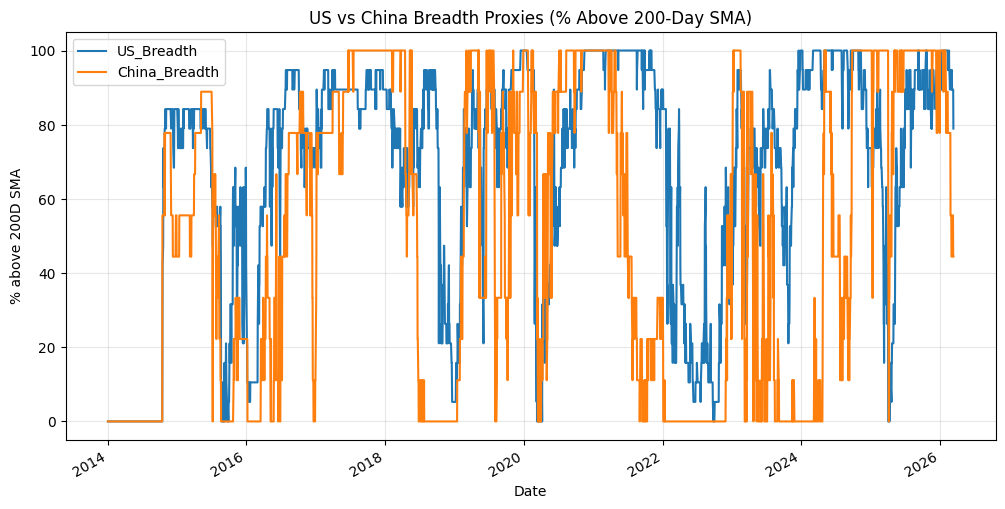

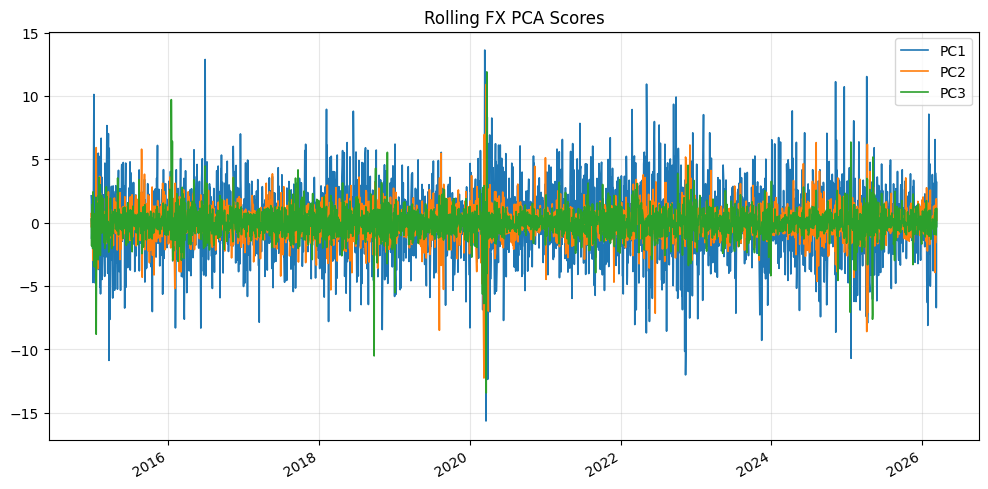

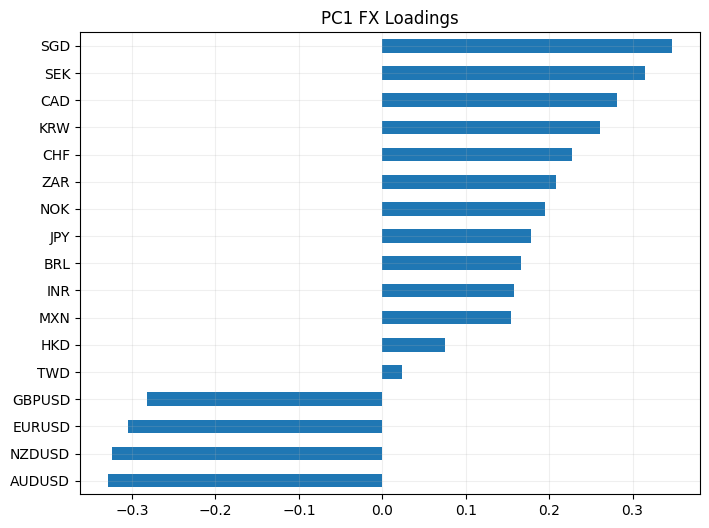

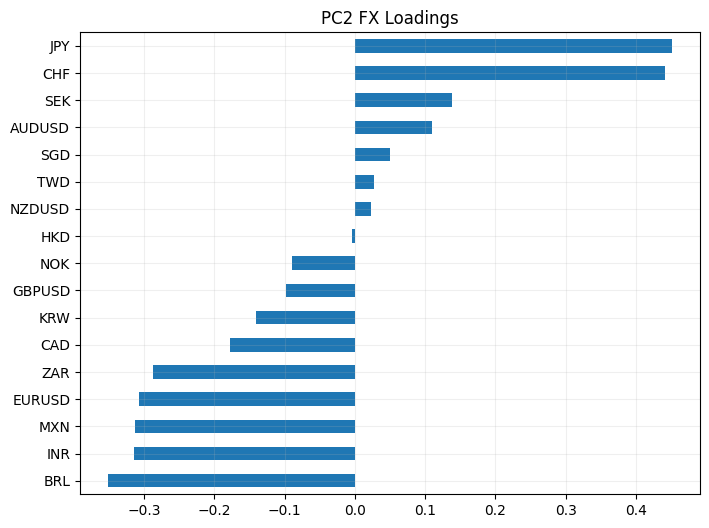

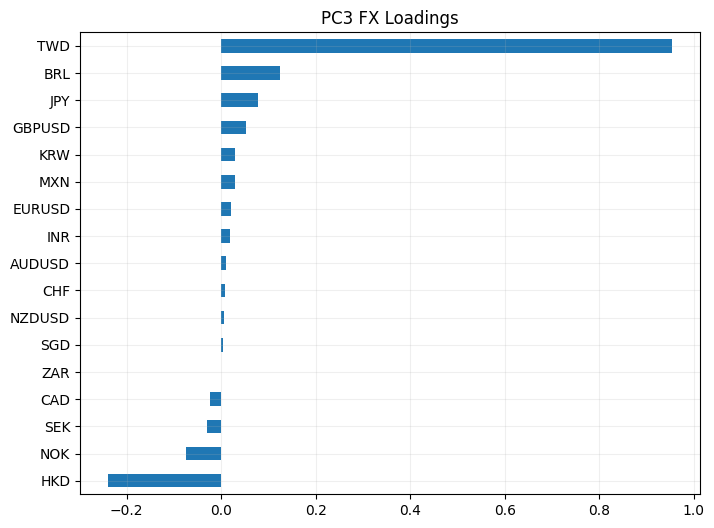


Single-asset predictive regressions:

===== AUDUSD =====
                             coef   tstat  pvalue
const                      0.0098  2.0216  0.0432
PC1                        0.0001  0.7893  0.4300
PC2                        0.0006  1.1978  0.2310
PC3                        0.0004  0.7133  0.4756
US_Breadth                -0.0001 -2.4765  0.0133
China_Breadth             -0.0000 -1.7393  0.0820
US_Breadth_5dChange        0.0002  2.5074  0.0122
China_Breadth_5dChange    -0.0000 -0.5157  0.6061
US_Breadth_Z              -0.0003 -0.5433  0.5869
China_Breadth_Z           -0.0003 -0.4394  0.6603
Breadth_Spread            -0.0001 -1.8042  0.0712
Breadth_Z_Spread          -0.0001 -0.1318  0.8951
R2                         0.0337     NaN     NaN
N                       2787.0000     NaN     NaN

===== NZDUSD =====
                             coef   tstat  pvalue
const                      0.0106  2.0230  0.0431
PC1                        0.0001  0.5101  0.6100
PC2                   

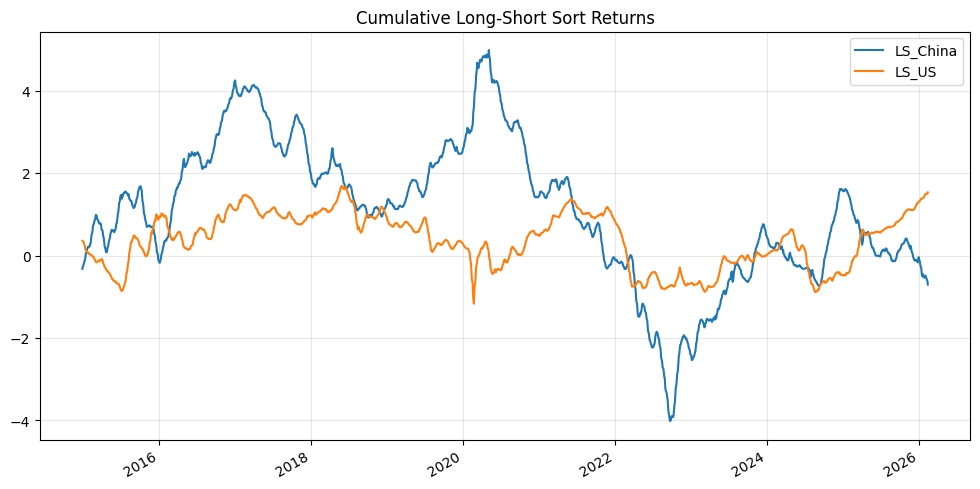


Saved key outputs to CSV in the current working directory.


In [16]:
# ============================================================
# FX PCA + US/China Breadth Proxy Study
# No pre-existing data required
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ---------------------------
# Settings
# ---------------------------
START = "2014-01-01"
END = None
SMA_WINDOW = 200
BREADTH_Z_WINDOW = 252
HORIZON = 20
N_COMPONENTS = 5
ROLLING_PCA_WINDOW = 252
MIN_PCA_OBS = 252

# ---------------------------
# 1. FX universe
# ---------------------------
# These are Yahoo Finance FX tickers.
# Sign conventions differ across pairs, so interpretation comes from PCA loadings/correlations.
FX_TICKERS = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "AUDUSD": "AUDUSD=X",
    "NZDUSD": "NZDUSD=X",
    "JPY": "JPY=X",
    "CAD": "CAD=X",
    "CHF": "CHF=X",
    "SEK": "SEK=X",
    "NOK": "NOK=X",
    "MXN": "MXN=X",
    "BRL": "BRL=X",
    "ZAR": "ZAR=X",
    "INR": "INR=X",
    "KRW": "KRW=X",
    "SGD": "SGD=X",
    "TWD": "TWD=X",
    "HKD": "HKD=X",
}

# ---------------------------
# 2. Breadth proxy universes
# ---------------------------
# US breadth proxy: broad US market + sector/size/style ETFs
US_UNIVERSE = [
    "SPY", "QQQ", "IWM", "DIA",
    "XLF", "XLK", "XLI", "XLE", "XLY", "XLP",
    "XLV", "XLB", "XLU", "XLRE", "XLC",
    "SMH", "SOXX", "KRE", "IBB"
]

# China breadth proxy: large cap, internet, A-shares, Hong Kong, EM-China linked ETFs
CHINA_UNIVERSE = [
    "FXI", "MCHI", "KWEB", "ASHR", "CNYA",
    "GXC", "PGJ", "CNXT", "EWH"
]

# ---------------------------
# 3. Predictive target assets
# ---------------------------
TARGETS = {
    "AUDUSD": "AUDUSD=X",
    "NZDUSD": "NZDUSD=X",
    "CNH": "CNH=X",
    "KRW": "KRW=X",
    "FXI": "FXI",
    "ASHR": "ASHR",
    "MCHI": "MCHI",
    "EEM": "EEM",
    "UUP": "UUP",
}

# ---------------------------
# Helpers
# ---------------------------
def download_prices(tickers, start=START, end=END):
    """
    Download adjusted close prices from Yahoo Finance.
    Works with a dict {name: ticker} or a list of tickers.
    """
    if isinstance(tickers, dict):
        raw = yf.download(
            list(tickers.values()),
            start=start,
            end=end,
            auto_adjust=True,
            progress=False,
            group_by="ticker",
        )
        out = pd.DataFrame(index=raw.index)

        for name, ticker in tickers.items():
            try:
                out[name] = raw[ticker]["Close"]
            except Exception:
                out[name] = np.nan

        return out.sort_index()

    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
    )

    if isinstance(raw.columns, pd.MultiIndex):
        return raw["Close"].sort_index()

    return raw.rename("Close").to_frame().sort_index()


def log_returns(prices):
    return np.log(prices / prices.shift(1)).dropna(how="all")


def forward_log_returns(prices, horizon=20):
    return np.log(prices.shift(-horizon) / prices)


def compute_breadth(prices, sma_window=200):
    sma = prices.rolling(sma_window).mean()
    above = (prices > sma).astype(float)
    breadth = 100 * above.mean(axis=1)
    return breadth.rename("Breadth")


def add_breadth_features(df, us_col="US_Breadth", cn_col="China_Breadth"):
    out = df.copy()

    out["US_Breadth_5dChange"] = out[us_col].diff(5)
    out["China_Breadth_5dChange"] = out[cn_col].diff(5)

    out["US_Breadth_Z"] = (
        (out[us_col] - out[us_col].rolling(BREADTH_Z_WINDOW).mean())
        / out[us_col].rolling(BREADTH_Z_WINDOW).std()
    )

    out["China_Breadth_Z"] = (
        (out[cn_col] - out[cn_col].rolling(BREADTH_Z_WINDOW).mean())
        / out[cn_col].rolling(BREADTH_Z_WINDOW).std()
    )

    out["Breadth_Spread"] = out[us_col] - out[cn_col]
    out["Breadth_Z_Spread"] = out["US_Breadth_Z"] - out["China_Breadth_Z"]

    return out


def prepare_pca_panel(returns, min_obs=MIN_PCA_OBS):
    valid_counts = returns.notna().sum()
    keep_cols = valid_counts[valid_counts >= min_obs].index.tolist()
    dropped_cols = [col for col in returns.columns if col not in keep_cols]

    if dropped_cols:
        print(f"Dropping sparse FX series before PCA: {dropped_cols}")

    clean = returns[keep_cols].dropna()

    if clean.empty:
        raise ValueError(
            "No overlapping FX return history remains after filtering sparse columns. "
            "Check Yahoo coverage or lower MIN_PCA_OBS."
        )

    return clean


def run_pca(returns, n_components=5):
    clean = prepare_pca_panel(returns)
    n_components = min(n_components, clean.shape[0], clean.shape[1])
    scaler = StandardScaler()
    X = scaler.fit_transform(clean)

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X)

    score_df = pd.DataFrame(
        scores,
        index=clean.index,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=clean.columns,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    explained = pd.Series(
        pca.explained_variance_ratio_,
        index=[f"PC{i+1}" for i in range(n_components)],
        name="ExplainedVarianceRatio"
    )

    return score_df, loadings, explained


def rolling_pca_scores(returns, window=252, n_components=3):
    clean = prepare_pca_panel(returns)

    if clean.shape[0] < window:
        raise ValueError(
            f"Not enough overlapping FX history for rolling PCA: {clean.shape[0]} rows, window={window}."
        )

    n_components = min(n_components, clean.shape[0], clean.shape[1])
    pcs = [f"PC{i+1}" for i in range(n_components)]

    scores_out = []
    loading_hist = []

    for i in range(window, len(clean) + 1):
        sub = clean.iloc[i-window:i]

        scaler = StandardScaler()
        X = scaler.fit_transform(sub)

        pca = PCA(n_components=n_components)
        scores = pca.fit_transform(X)

        scores_out.append(
            pd.Series(scores[-1], index=pcs, name=sub.index[-1])
        )

        loadings = pd.DataFrame(
            pca.components_.T,
            index=sub.columns,
            columns=pcs
        )
        loadings["date"] = sub.index[-1]
        loading_hist.append(loadings.reset_index().rename(columns={"index": "asset"}))

    return pd.DataFrame(scores_out), pd.concat(loading_hist, ignore_index=True)


def pick_best_pc(pc_scores, proxy, proxy_name):
    tmp = pd.concat([pc_scores, proxy.rename(proxy_name)], axis=1).dropna()
    corr = tmp.corr()[proxy_name].drop(proxy_name)
    corr = corr.sort_values(key=np.abs, ascending=False)
    return corr.index[0], corr


def ols_table(df, y_col, x_cols, min_obs=120):
    reg = df[[y_col] + x_cols].dropna()
    if len(reg) < min_obs:
        return None

    X = sm.add_constant(reg[x_cols])
    y = reg[y_col]
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    out = pd.DataFrame({
        "coef": model.params,
        "tstat": model.tvalues,
        "pvalue": model.pvalues,
    })
    out.loc["R2", "coef"] = model.rsquared
    out.loc["N", "coef"] = len(reg)
    return out


def panel_interaction_test(fwd_returns, predictor, exposure, predictor_name, exposure_name):
    y = fwd_returns.stack().rename("y").reset_index()
    y.columns = ["Date", "Asset", "y"]

    p = predictor.rename(predictor_name).reset_index()
    p.columns = ["Date", predictor_name]

    e = exposure.rename(exposure_name).reset_index()
    e.columns = ["Asset", exposure_name]

    df = y.merge(p, on="Date", how="left").merge(e, on="Asset", how="left")
    df["interaction"] = df[predictor_name] * df[exposure_name]
    df = df.dropna()

    if len(df) < 200:
        return None, df

    X = sm.add_constant(df[[predictor_name, exposure_name, "interaction"]])
    model = sm.OLS(df["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    out = pd.DataFrame({
        "coef": model.params,
        "tstat": model.tvalues,
        "pvalue": model.pvalues,
    })
    out.loc["R2", "coef"] = model.rsquared
    out.loc["N", "coef"] = len(df)

    return out, df


# ============================================================
# A. Download data
# ============================================================
print("Downloading FX prices...")
fx_prices = download_prices(FX_TICKERS).dropna(axis=1, how="all")

print("Downloading breadth proxy prices...")
us_prices = download_prices(US_UNIVERSE).dropna(axis=1, how="all")
china_prices = download_prices(CHINA_UNIVERSE).dropna(axis=1, how="all")

print("Downloading predictive target prices...")
target_prices = download_prices(TARGETS).dropna(axis=1, how="all")

# Optional benchmark series
benchmark = download_prices({"CSI300": "000300.SS", "SPX": "^GSPC"}).dropna(axis=1, how="all")

print("\nAvailable FX columns:")
print(fx_prices.columns.tolist())

print("\nAvailable US breadth proxy columns:")
print(us_prices.columns.tolist())

print("\nAvailable China breadth proxy columns:")
print(china_prices.columns.tolist())


# ============================================================
# B. Build breadth proxies
# ============================================================
us_breadth = compute_breadth(us_prices, sma_window=SMA_WINDOW).rename("US_Breadth")
china_breadth = compute_breadth(china_prices, sma_window=SMA_WINDOW).rename("China_Breadth")

breadth_df = pd.concat([us_breadth, china_breadth], axis=1)
breadth_df = add_breadth_features(breadth_df)

print("\nBreadth head:")
print(breadth_df.tail())


# ============================================================
# C. FX returns and PCA
# ============================================================
fx_ret = log_returns(fx_prices)
pc_scores, loadings, explained = run_pca(fx_ret, n_components=N_COMPONENTS)

print("\nExplained variance:")
print(explained.round(4))

rolling_scores, rolling_loading_hist = rolling_pca_scores(
    fx_ret,
    window=ROLLING_PCA_WINDOW,
    n_components=min(3, N_COMPONENTS)
)

# Merge factors with breadth
factors = pd.concat([rolling_scores, breadth_df], axis=1).dropna()


# ============================================================
# D. Identify US-like and China-like FX factors
# ============================================================
proxy_df = pd.concat(
    [
        pc_scores,
        us_breadth,
        china_breadth,
        benchmark,
    ],
    axis=1
).dropna()

corr_mat = proxy_df.corr().loc[
    [c for c in pc_scores.columns],
    [c for c in proxy_df.columns if c not in pc_scores.columns]
]

print("\nPC correlations with breadth/index proxies:")
print(corr_mat.round(3))

usd_pc, usd_corr = pick_best_pc(pc_scores, us_breadth, "US_Breadth")
china_pc, china_corr = pick_best_pc(pc_scores, china_breadth, "China_Breadth")

print(f"\nChosen US-related PC: {usd_pc}")
print(usd_corr.round(3))

print(f"\nChosen China-related PC: {china_pc}")
print(china_corr.round(3))

usd_exposure = loadings[usd_pc].rename("USD_Exposure")
china_exposure = loadings[china_pc].rename("China_Exposure")


# ============================================================
# E. Plot diagnostics
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
breadth_df[["US_Breadth", "China_Breadth"]].plot(ax=ax, linewidth=1.5)
ax.set_title("US vs China Breadth Proxies (% Above 200-Day SMA)")
ax.set_ylabel("% above 200D SMA")
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
rolling_scores.plot(ax=ax, linewidth=1.2)
ax.set_title("Rolling FX PCA Scores")
ax.grid(alpha=0.3)
plt.show()

for pc in ["PC1", "PC2", "PC3"]:
    if pc in loadings.columns:
        s = loadings[pc].sort_values()
        fig, ax = plt.subplots(figsize=(8, 6))
        s.plot(kind="barh", ax=ax)
        ax.set_title(f"{pc} FX Loadings")
        ax.grid(alpha=0.2)
        plt.show()


# ============================================================
# F. Predict future returns of targets
# ============================================================
target_fwd = forward_log_returns(target_prices, horizon=HORIZON)

predictor_cols = [c for c in [
    "PC1", "PC2", "PC3",
    "US_Breadth", "China_Breadth",
    "US_Breadth_5dChange", "China_Breadth_5dChange",
    "US_Breadth_Z", "China_Breadth_Z",
    "Breadth_Spread", "Breadth_Z_Spread"
] if c in factors.columns]

single_asset_results = {}

for asset in target_fwd.columns:
    y = target_fwd[asset].rename(f"{asset}_fwd_{HORIZON}d")
    df = pd.concat([factors, y], axis=1)

    res = ols_table(df, y.name, predictor_cols)
    if res is not None:
        single_asset_results[asset] = res

print("\nSingle-asset predictive regressions:")
for asset, table in single_asset_results.items():
    print(f"\n===== {asset} =====")
    print(table.round(4))


# ============================================================
# G. Predict future FX returns directly
# ============================================================
fx_fwd = forward_log_returns(fx_prices, horizon=HORIZON)

fx_results = {}
for asset in fx_fwd.columns:
    y = fx_fwd[asset].rename(f"{asset}_fwd_{HORIZON}d")
    df = pd.concat([factors, y], axis=1)

    res = ols_table(df, y.name, predictor_cols)
    if res is not None:
        fx_results[asset] = res

print("\nFX predictive regressions:")
for asset, table in fx_results.items():
    print(f"\n===== {asset} =====")
    print(table.round(4))


# ============================================================
# H. Exposure interaction tests
# Do high-China-exposure currencies respond more to China breadth?
# ============================================================
common_fx = fx_fwd.columns.intersection(china_exposure.index).intersection(usd_exposure.index)
fx_fwd_panel = fx_fwd[common_fx]

china_panel_res, china_panel_df = panel_interaction_test(
    fx_fwd_panel,
    predictor=factors["China_Breadth_Z"],
    exposure=china_exposure.loc[common_fx],
    predictor_name="China_Breadth_Z",
    exposure_name="China_Exposure",
)

us_panel_res, us_panel_df = panel_interaction_test(
    fx_fwd_panel,
    predictor=factors["US_Breadth_Z"],
    exposure=usd_exposure.loc[common_fx],
    predictor_name="US_Breadth_Z",
    exposure_name="USD_Exposure",
)

print("\nPanel interaction test: China breadth x China exposure")
print(china_panel_res.round(4) if china_panel_res is not None else "Not enough data")

print("\nPanel interaction test: US breadth x USD exposure")
print(us_panel_res.round(4) if us_panel_res is not None else "Not enough data")


# ============================================================
# I. Long-short sort test
# Score_{i,t} = predictor_t * exposure_i
# ============================================================
def quantile_sort_ls(fwd_returns, predictor, exposure, q=3):
    rets = []
    dates = []

    common_assets = fwd_returns.columns.intersection(exposure.index)

    for dt in predictor.dropna().index:
        if dt not in fwd_returns.index:
            continue

        y = fwd_returns.loc[dt, common_assets].dropna()
        if len(y) < q:
            continue

        score = predictor.loc[dt] * exposure.loc[y.index]
        tmp = pd.DataFrame({"y": y, "score": score}).dropna()

        try:
            tmp["bucket"] = pd.qcut(tmp["score"], q=q, labels=False, duplicates="drop")
        except Exception:
            continue

        if tmp["bucket"].nunique() < 2:
            continue

        long_ret = tmp.loc[tmp["bucket"] == tmp["bucket"].max(), "y"].mean()
        short_ret = tmp.loc[tmp["bucket"] == tmp["bucket"].min(), "y"].mean()

        rets.append(long_ret - short_ret)
        dates.append(dt)

    return pd.Series(rets, index=dates)

ls_china = quantile_sort_ls(
    fx_fwd_panel,
    factors["China_Breadth_Z"],
    china_exposure.loc[common_fx],
    q=3,
).rename("LS_China")

ls_us = quantile_sort_ls(
    fx_fwd_panel,
    factors["US_Breadth_Z"],
    usd_exposure.loc[common_fx],
    q=3,
).rename("LS_US")

ls_df = pd.concat([ls_china, ls_us], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
ls_df.cumsum().plot(ax=ax, linewidth=1.5)
ax.set_title("Cumulative Long-Short Sort Returns")
ax.grid(alpha=0.3)
plt.show()


# ============================================================
# J. Save outputs if you want
# ============================================================
pc_scores.to_csv("fx_pc_scores_fullsample.csv")
loadings.to_csv("fx_pc_loadings_fullsample.csv")
rolling_scores.to_csv("fx_pc_scores_rolling.csv")
breadth_df.to_csv("breadth_proxy_features.csv")
fx_prices.to_csv("fx_prices.csv")
target_prices.to_csv("target_prices.csv")

print("\nSaved key outputs to CSV in the current working directory.")